# Principle Components Analysis

## Import the Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np

Use `Digit recognizer` dataset for PCA, It has a `42000` rows and `785` columns

In [2]:
df = pd.read_csv('E:\Machine-Learning\ML_Preprocessing\Feature Engineering\PCA\data_recognizer_dataset\\train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(42000, 785)

In [4]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
39189,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Take an example how they data shown so we take a sample value and try to plot this

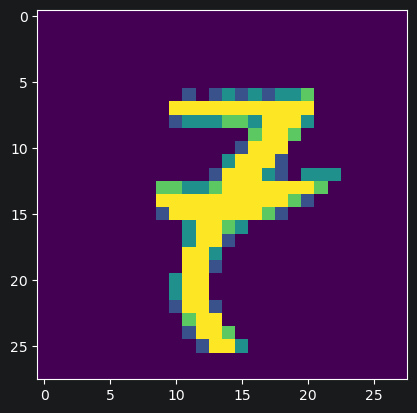

In [5]:
import matplotlib.pyplot as plt

plt.imshow(df.iloc[13042, 1:].values.reshape(28, 28))

## Split the dataset

In [6]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [8]:
X_train.shape

(33600, 784)

## Train the model

In [9]:
from sklearn.neighbors import KNeighborsClassifier

In [10]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
import time
strt = time.time()

y_pred = knn.predict(X_test)

print(time.time() - strt)

8.272886514663696


In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9648809523809524

## Perform PCA

In [13]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [14]:
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [15]:
# PCA
from sklearn.decomposition import PCA
pca= PCA(n_components=200)

In [16]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

After `PCA` we got the transformed data and its shape is now `(33600, 200)` 

In [17]:
X_train_trf.shape

(33600, 200)

In [18]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
y_pred1 = knn.predict(X_test_trf)

In [20]:
accuracy_score(y_test, y_pred1)

0.9507142857142857

We apply a loop so we found the correct and true `no_components` which we need to get higher accuracy in less dimension.

In [21]:
# for i in range(1, 785):
#     pca = PCA(n_components=i)
#     X_train_trf = pca.fit_transform(X_train)
#     X_test_trf = pca.transform(X_test)
#
#     knn = KNeighborsClassifier()
#     knn.fit(X_train_trf, y_train)
#     y_pred2 = knn.predict(X_test_trf)
#     print(f'In N_component {i} : accuracy is {accuracy_score(y_test, y_pred2):.3f}')

### Transform to a 2D coordinate system

In [22]:
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train_trf)
X_test_trf = pca.transform(X_test_trf)

In [23]:
X_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]], shape=(33600, 2))

plot the transformed data

In [24]:
import plotly.express as px
y_train_trf = y_train.astype(str)

fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                color=y_train_trf,
                color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

### Transform in 3D

In [25]:
pca=PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [26]:
X_train_trf


array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]], shape=(33600, 3))

In [27]:
y_train_trf = y_train.astype(str)

fig = px.scatter_3d(df,
                    x=X_train_trf[:,0],
                    y=X_train_trf[:,1],
                    z=X_train_trf[:,2],
                    color=y_train_trf,
                    color_discrete_sequence=px.colors.qualitative.G10
                )
fig.update_layout(
    margin=dict(l=20,r=20, t=20, b=20)
)
fig.show()

ShapeError: Expected object of length 33600, got length: 42000

### Some parameters of pca class

In [ ]:
pca.explained_variance_
# Its  Eigen Values ......

In [ ]:
pca.components_.shape
# its Eigen Vector

In [ ]:
pca.explained_variance_ratio_*100

### lets find out the opotimal no. of principle components for this datasets

In [ ]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [ ]:
pca.explained_variance_.shape

In [ ]:
pca.components_.shape

In [ ]:
np.cumsum(pca.explained_variance_ratio_)

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))